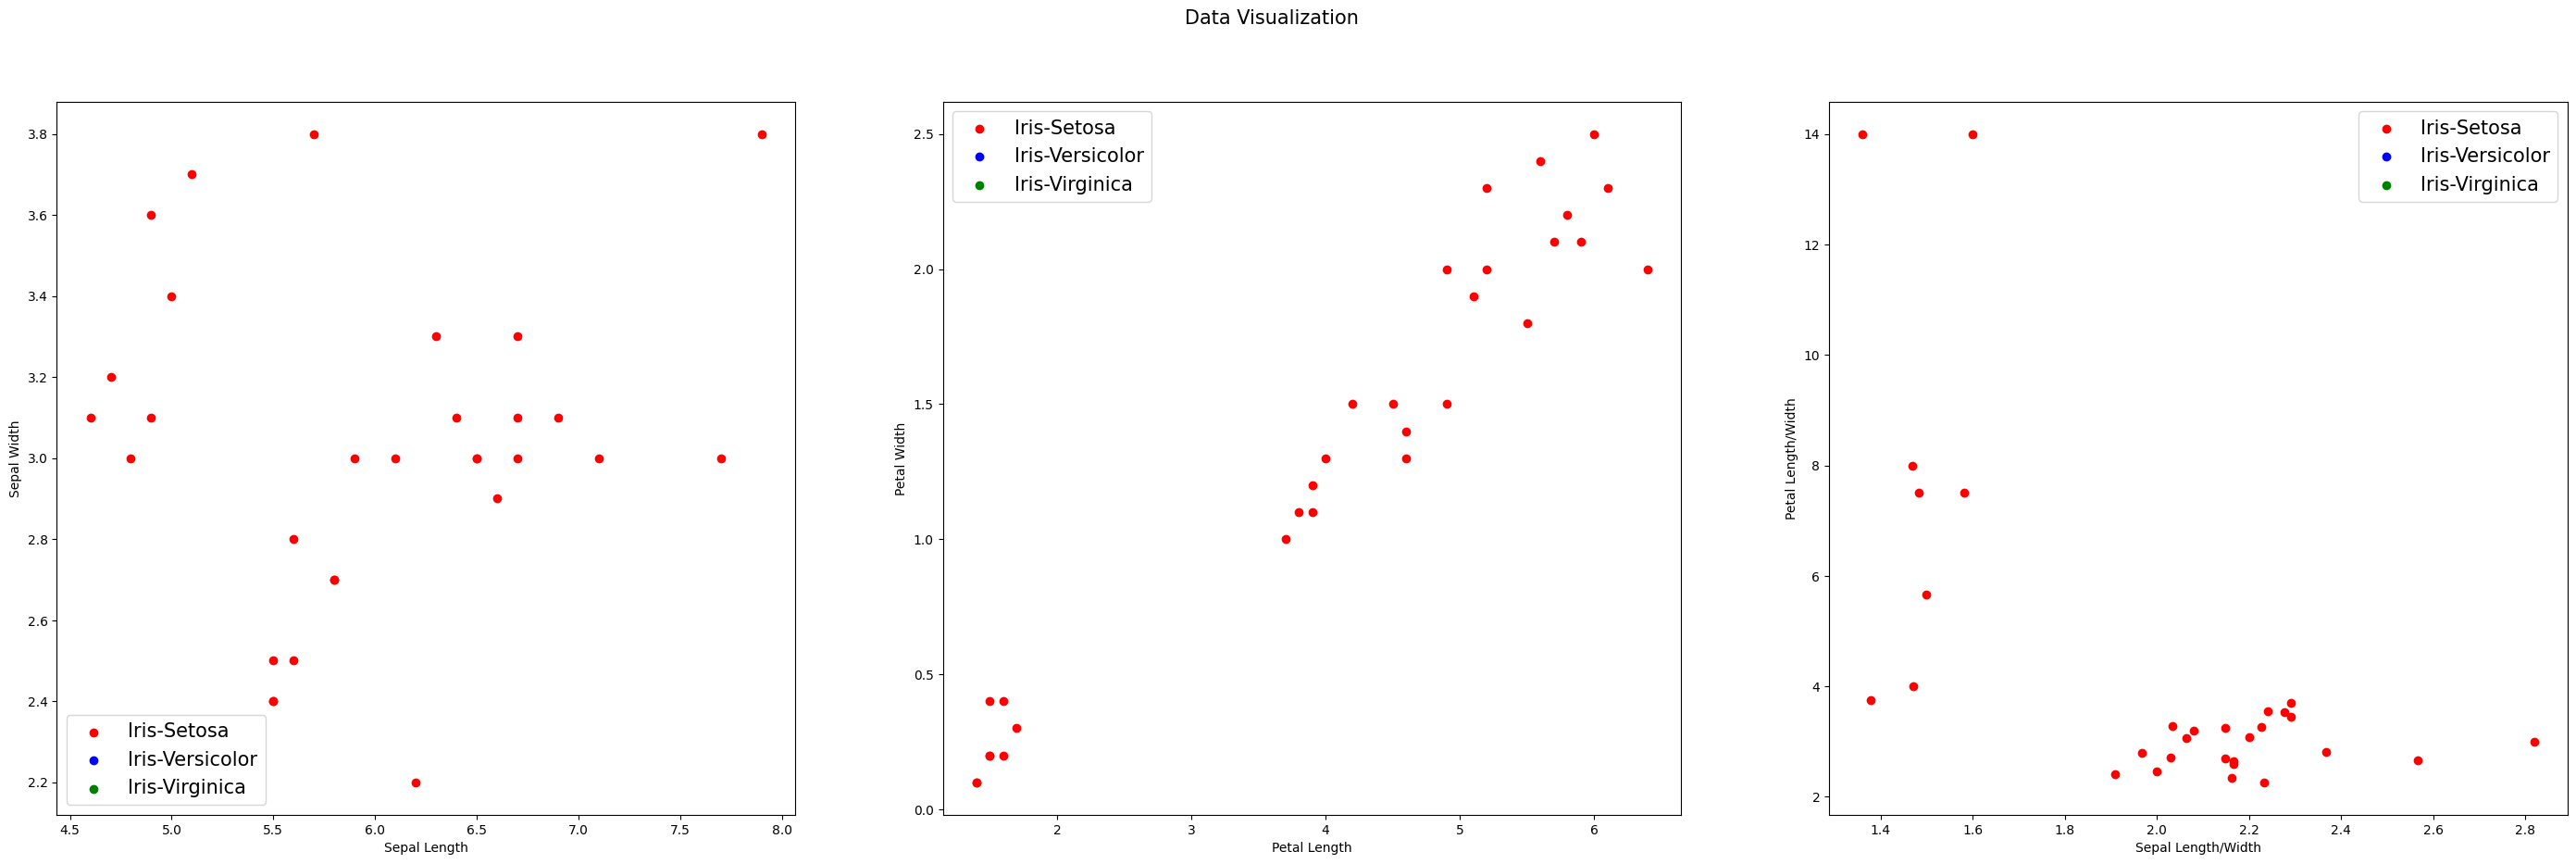

y_true ['Virginica' 'Versicolor' 'Versicolor' 'Virginica' 'Setosa' 'Versicolor'
 'Versicolor' 'Setosa' 'Setosa' 'Versicolor' 'Virginica' 'Versicolor'
 'Virginica' 'Versicolor' 'Setosa' 'Versicolor' 'Virginica' 'Versicolor'
 'Virginica' 'Virginica' 'Virginica' 'Setosa' 'Virginica' 'Virginica'
 'Setosa' 'Versicolor' 'Setosa' 'Setosa' 'Virginica' 'Virginica'] 
y_pred ['Virginica', 'Versicolor', 'Versicolor', 'Virginica', 'Setosa', 'Versicolor', 'Versicolor', 'Setosa', 'Setosa', 'Versicolor', 'Virginica', 'Versicolor', 'Virginica', 'Virginica', 'Setosa', 'Versicolor', 'Virginica', 'Versicolor', 'Virginica', 'Virginica', 'Virginica', 'Setosa', 'Virginica', 'Virginica', 'Setosa', 'Versicolor', 'Setosa', 'Setosa', 'Virginica', 'Virginica']
Naive Bayes Classification Accuracy: 96.67%


In [ ]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# read_data, get_df_shape, data_split are the same as HW3
def read_data(filename: str) -> pd.DataFrame:
    d = pd.read_csv(filename)
    df = pd.DataFrame(data=d)
    return df

class GaussianNaiveBayes:
    def __init__(self, eps=1e-6):
        self.classes = None
        self.mean = None
        self.var = None
        self.priors = None
        self.eps = eps  # small constant to avoid division by zero

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Train the Gaussian Naive Bayes model. Calculate the mean, variance, and prior probabilities for each class.

        Parameters:
        X : np.ndarray
            The training features
        y : np.ndarray
            The training labels

        Returns:
        mean : np.ndarray
              The mean for each class
        var : np.ndarray
              The variance for each class
        priors : np.ndarray
              The prior probabilities for each class
        """
        # Get the unique classes in y
        unique_classes = np.unique(y)

        # Initialize arrays to store mean, variance, and prior probabilities
        mean = np.zeros((len(unique_classes), X.shape[1]))
        var = np.zeros((len(unique_classes), X.shape[1]))
        priors = np.zeros(len(unique_classes))

        # Calculate mean, variance, and prior for each class
        for i, class_label in enumerate(unique_classes):
            # Select data points belonging to the current class
            X_class = X[y == class_label]
            #print('x_class',X_class)
            # Calculate mean and variance for each feature
            mean[i, :] = np.mean(X_class, axis=0)
            var[i, :] = np.var(X_class, axis=0)

            # Calculate prior probability for the class
            priors[i] = len(X_class) / len(y)
        #print('mean ',mean,'\n var ',var,'\n priors ',priors)
        self.mean = mean
        self.var = var
        self.priors = priors
        #print('mean ',self.mean,'\n var ',self.var,'\n priors ',self.priors)
        return mean, var, priors
        pass

    def gaussian_probability(self, x: np.ndarray, mu: np.ndarray, sigma2: np.ndarray) -> np.ndarray:
        """
        Compute the Gaussian probability.

        Parameters:
        x : np.ndarray
            The input features
        mu : np.ndarray
            The mean values
        sigma2 : np.ndarray
            The variance values

        Returns:
        np.ndarray
            The Gaussian probabilities
        """
        #print('sigma2',sigma2)
        exponent = -0.5 * ((x - mu)** 2)/(sigma2)
        #print('exp',exponent)
        # Calculate the coefficient term
        coefficient = 1 /(np.sqrt(2 * np.pi * sigma2))
        #print('coef',coefficient)
        # Compute the Gaussian probabilities
        #print('ex',np.exp(exponent))
        probabilities = coefficient * np.exp(exponent)
        #print('prob', probabilities)
        #self.classes = probabilities
        #print(self.classes)
        return probabilities
        pass

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Make predictions for given features using the trained Gaussian Naive Bayes model.

        Parameters:
        X : np.ndarray
            The features to predict

        Returns:
        np.ndarray
            The predicted classes
        """
        num_samples, num_features = X.shape
        #print('class',  self.classes)
        num_classes = 3#len(self.classes)  # Assuming you have a list of class labels

        # Initialize an array to store the predicted classes
        predictions = np.zeros(num_samples, dtype=int)

        for i in range(num_samples):
            # Calculate the log likelihoods for each class
            log_likelihoods = np.zeros(num_classes)

            for j in range(num_classes):
                    # Calculate the Gaussian probability for each feature
                feature_probs = self.gaussian_probability(X[i], self.mean[j], self.var[j])

            # Calculate the log likelihood for this class
                log_likelihoods[j] = np.sum(np.log(feature_probs))

            # Calculate the log posterior probabilities (adding the log prior here if needed)
            log_posteriors = log_likelihoods  # In Naive Bayes, we don't explicitly calculate priors

            # Assign the class with the highest log posterior as the predicted class
            predictions[i] = np.argmax(log_posteriors)
        fowler_list = []
        for i in range(len(predictions)):
            if predictions[i] == 0:
                fowler_list.append('Setosa')
            elif predictions[i] == 1:
                fowler_list.append('Versicolor')
            elif predictions[i] == 2:
                fowler_list.append('Virginica')
        #self.classes = predictions
        return fowler_list
        pass


def visualization(df: pd.DataFrame):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(35, 10))
    fig.suptitle("Data Visualization", fontsize=15)

    X = np.asarray(df.drop('variety', axis=1))
    x1, x2, x3, x4 = X.T[0], X.T[1], X.T[2], X.T[3]

    ax1.scatter(x1[:50], x2[:50], c='red')
    ax1.scatter(x1[50:100], x2[50:100], c='blue')
    ax1.scatter(x1[100:150], x2[100:150], c='green')
    ax1.set(xlabel='Sepal Length', ylabel='Sepal Width')

    ax2.scatter(x3[0:50], x4[0:50], c='red')
    ax2.scatter(x3[50:100], x4[50:100], c='blue')
    ax2.scatter(x3[100:150], x4[100:150], c='green')
    ax2.set(xlabel='Petal Length', ylabel="Petal Width")

    ax3.scatter(x1[:50]/x2[:50], x3[0:50]/x4[0:50], c='red')
    ax3.scatter(x1[50:100]/x2[50:100], x3[50:100]/x4[50:100], c='blue')
    ax3.scatter(x1[100:150]/x2[100:150], x3[100:150]/x4[100:150], c='green')
    ax3.set(xlabel='Sepal Length/Width', ylabel='Petal Length/Width')

    ax1.legend(['Iris-Setosa', 'Iris-Versicolor',
               'Iris-Virginica'], fontsize=15)
    ax2.legend(['Iris-Setosa', 'Iris-Versicolor',
               'Iris-Virginica'], fontsize=15)
    ax3.legend(['Iris-Setosa', 'Iris-Versicolor',
               'Iris-Virginica'], fontsize=15)

    plt.show()


# Testing
if __name__ == "__main__":
    def accuracy(y_true, y_pred):
        print('y_true',y_true,'\ny_pred',y_pred)
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy

    # Read the data
    train_df = read_data("./iris_training_data.csv")
    test_df = read_data("./iris_testing_data.csv")

    # Visualization for you to understand the data, you can comment it out
    # visualization(test_df)

    # Data preprocessing
    train_features = train_df.drop('variety', axis=1).values
    train_labels = train_df['variety'].values

    test_features = test_df.drop('variety', axis=1).values
    test_labels = test_df['variety'].values

    # Get the number of features
    num_features = train_features.shape[1]

    # Initialize and train the Naive Bayes classifier
    nb = GaussianNaiveBayes()
    nb.fit(train_features, train_labels)

    # Make predictions on the test set
    test_predictions = nb.predict(test_features)

    # Calculate accuracy
    accuracy = accuracy(test_labels, test_predictions)
    print("Naive Bayes Classification Accuracy: {:.2f}%".format(
        accuracy * 100))
